# **Loading The Dataset**

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download teejmahal20/airline-passenger-satisfaction

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
License(s): other
100% 2.71M/2.71M [00:00<00:00, 176MB/s]



In [ ]:
!unzip /content/airline-passenger-satisfaction.zip

Archive:  /content/airline-passenger-satisfaction.zip
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def load_data():
    train = pd.read_csv("train.csv")
    test = pd.read_csv("test.csv")
    return train, test

train_df, test_df = load_data()

# **Dataset Shape**

In [ ]:
train_df.shape

(103904, 25)

In [ ]:
test_df.shape

(25976, 25)

# **Dataset columns**

In [ ]:
train_df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
features = {
    "Personal Data": ["Gender", "Age", "Customer Type"],
    "Travel Info": ["Type of Travel", "Class", "Flight Distance"],
    "Service Ratings": [
        "Inflight wifi service",
        "Departure/Arrival time convenient",
        "Inflight entertainment",
        "On-board service",
        "Leg room service",
        "Baggage handling",
        "Checkin service",
        "Inflight service",
        "Cleanliness"
    ],
    "Delays": ["Departure Delay in Minutes", "Arrival Delay in Minutes"],
    "Unnecessary Columns": ["Unnamed: 0", "id"]
}

for group, cols in features.items():
    print(f"\n{group}:")
    for col in cols:
        print(" -", col)


Personal Data:
 - Gender
 - Age
 - Customer Type

Travel Info:
 - Type of Travel
 - Class
 - Flight Distance

Service Ratings:
 - Inflight wifi service
 - Departure/Arrival time convenient
 - Inflight entertainment
 - On-board service
 - Leg room service
 - Baggage handling
 - Checkin service
 - Inflight service
 - Cleanliness

Delays:
 - Departure Delay in Minutes
 - Arrival Delay in Minutes

Unnecessary Columns:
 - Unnamed: 0
 - id


## **Target**

In [ ]:
target = "satisfaction"

In [ ]:

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
train_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
train_df.drop(columns=["Unnamed: 0", "id"], inplace=True, errors="ignore")
test_df.drop(columns=["Unnamed: 0", "id"], inplace=True, errors="ignore")

In [ ]:
print(train_df.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [ ]:
train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# **Visualization**

# **1-Stacked Bar**

In [ ]:
def stacked_bar_gender(train_df):
    pdf = train_df.copy()

    pivot = pdf.groupby(["Gender", "satisfaction"]).size().unstack()

    pivot.plot(kind="bar", stacked=True, figsize=(8,5))

    plt.title("Satisfaction by Gender (Stacked)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
def stacked_bar_class(train_df):
    pdf = train_df.copy()

    pivot = pdf.groupby(["Class", "satisfaction"]).size().unstack()

    pivot.plot(kind="bar", stacked=True, figsize=(8,5))

    plt.title("Satisfaction by Class (Stacked)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
def stacked_customer_type(train_df):
    pdf = train_df.copy()

    pivot = pdf.groupby(["Customer Type", "satisfaction"]).size().unstack()

    pivot.plot(kind="bar", stacked=True, figsize=(8,5))

    plt.title("Satisfaction by Customer Type")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
def stacked_travel_type(train_df):
    pdf = train_df.copy()

    pivot = pdf.groupby(["Type of Travel", "satisfaction"]).size().unstack()

    pivot.plot(kind="bar", stacked=True, figsize=(8,5))

    plt.title("Satisfaction by Travel Type")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

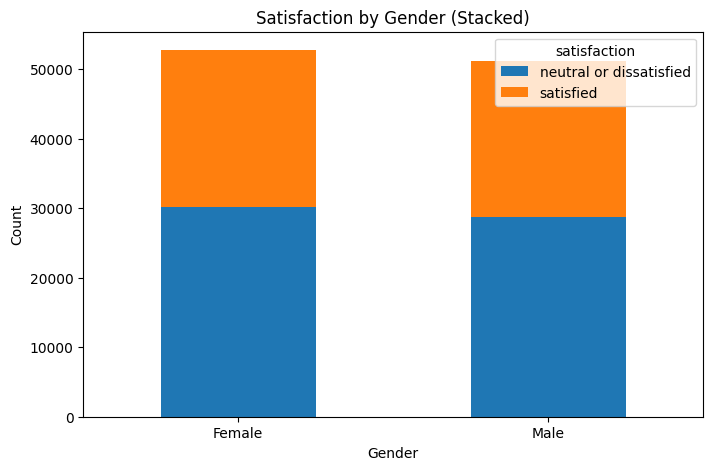

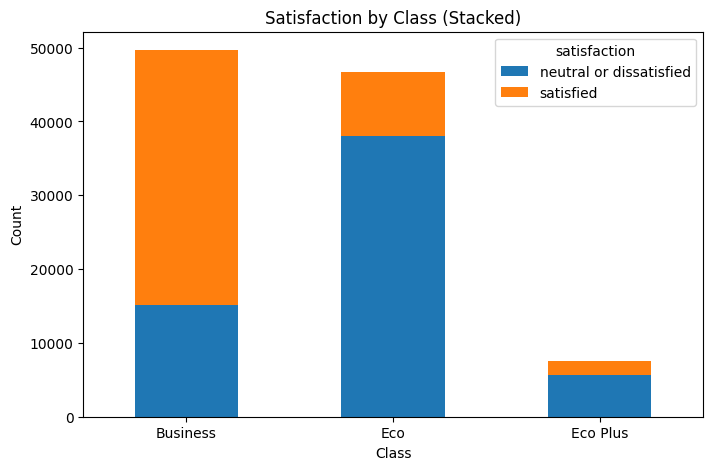

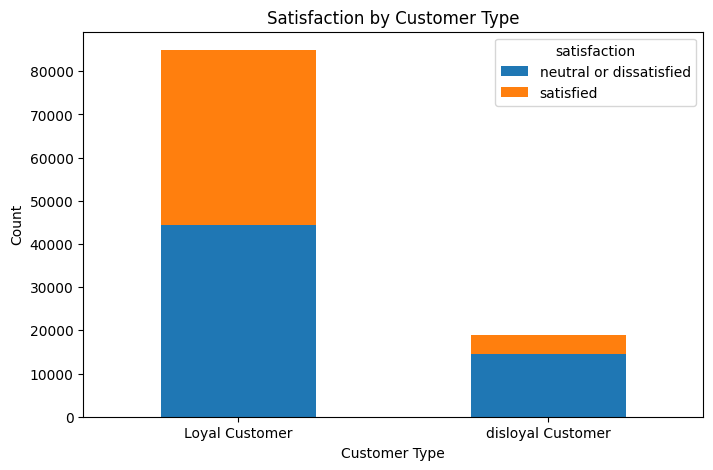

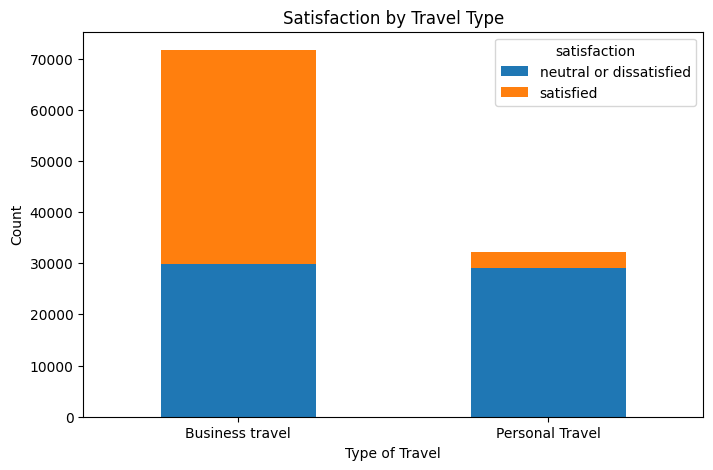

In [ ]:
stacked_bar_gender(train_df)
stacked_bar_class(train_df)
stacked_customer_type(train_df)
stacked_travel_type(train_df)

# **2-Scatter Plot**

In [ ]:
def scatter_age_distance(train_df):
    pdf = train_df.copy()

    plt.figure(figsize=(6,5))
    plt.scatter(pdf["Age"], pdf["Flight Distance"], alpha=0.4)

    plt.xlabel("Age")
    plt.ylabel("Flight Distance")
    plt.title("Age vs Flight Distance")
    plt.show()

In [ ]:
def scatter_delay(train_df):
    pdf = train_df.copy()

    plt.figure(figsize=(6,5))
    plt.scatter(pdf["Departure Delay in Minutes"],
                pdf["Arrival Delay in Minutes"], alpha=0.4)

    plt.xlabel("Departure Delay")
    plt.ylabel("Arrival Delay")
    plt.title("Departure vs Arrival Delay")
    plt.show()

In [ ]:
def scatter_service(train_df):
    pdf = train_df.copy()

    plt.figure(figsize=(6,5))
    plt.scatter(pdf["Online boarding"], pdf["Seat comfort"], alpha=0.5)

    plt.xlabel("Online Boarding")
    plt.ylabel("Seat Comfort")
    plt.title("Service Quality Relationship")
    plt.show()

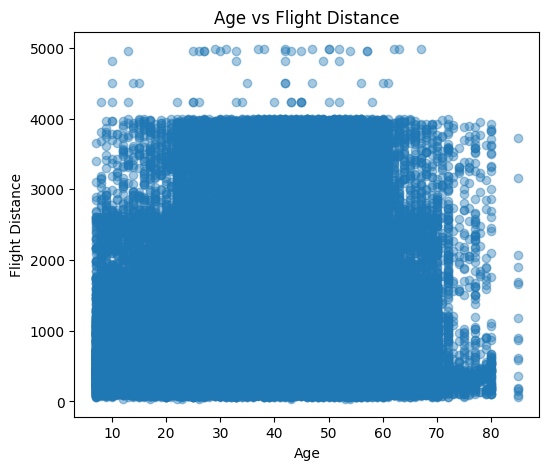

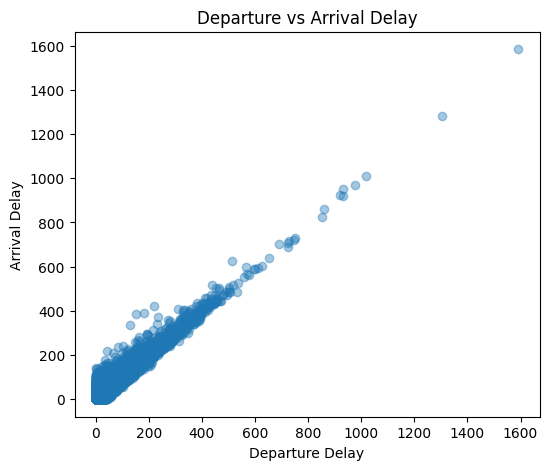

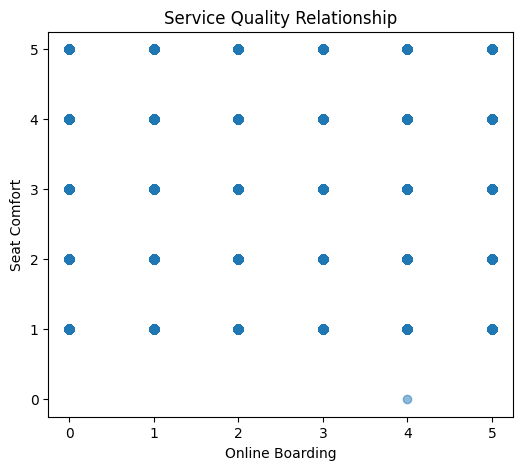

In [ ]:
scatter_age_distance(train_df)
scatter_delay(train_df)
scatter_service(train_df)

# **3-Heatmap**

In [ ]:
def heatmap(train_df):
    pdf = train_df.copy()


    pdf["satisfaction"] = pdf["satisfaction"].map({
        "satisfied": 1,
        "neutral or dissatisfied": 0
    })


    corr = pdf.corr(numeric_only=True)

    plt.figure(figsize=(12,8))
    sns.heatmap(corr, cmap="coolwarm", linewidths=0.3)

    plt.title("Correlation Heatmap")
    plt.show()

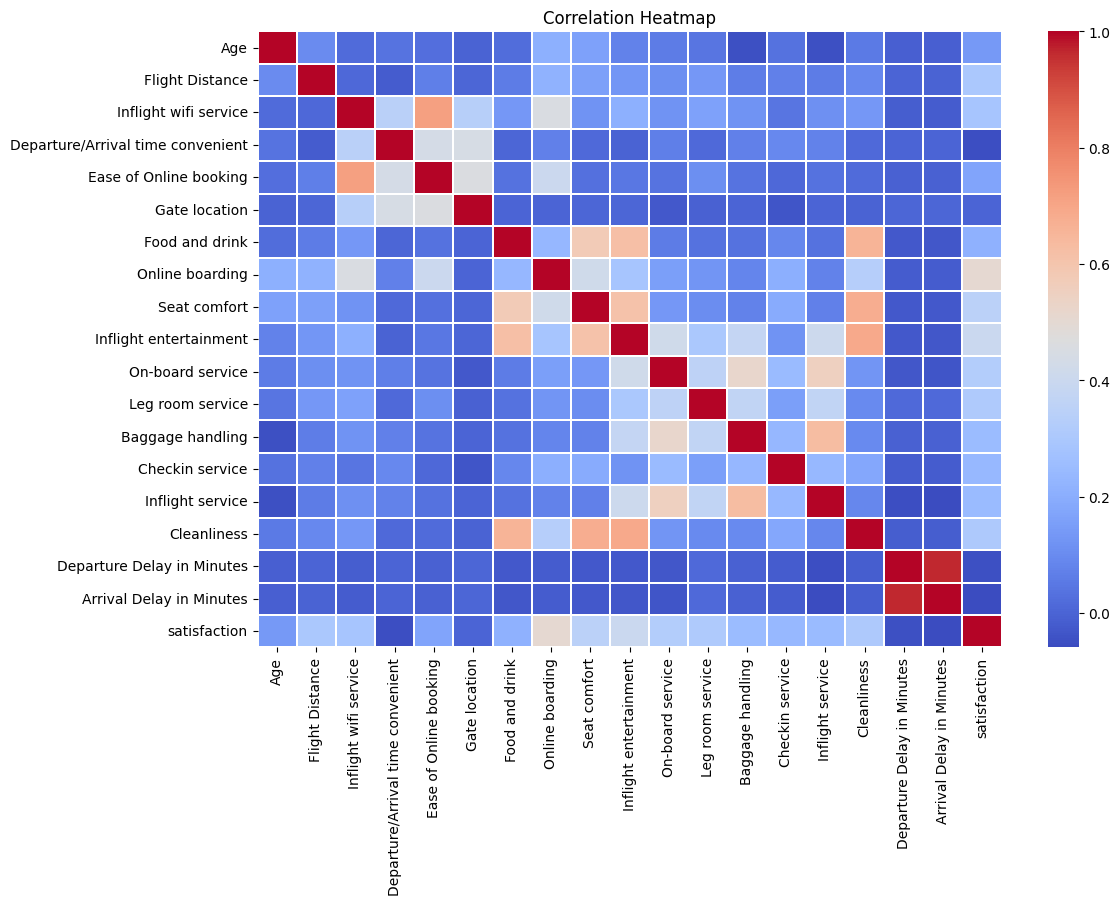

In [ ]:
heatmap(train_df)

# **4-Pie Chart**

In [ ]:
def plot_pie(data, column, title):
    import matplotlib.pyplot as plt

    data[column].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        figsize=(6,6)
    )
    plt.title(title)
    plt.ylabel("")
    plt.show()

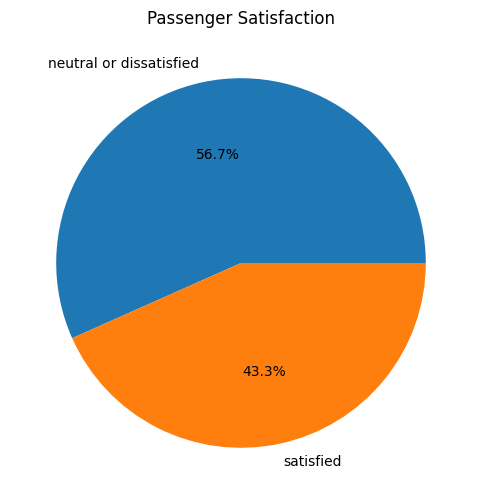

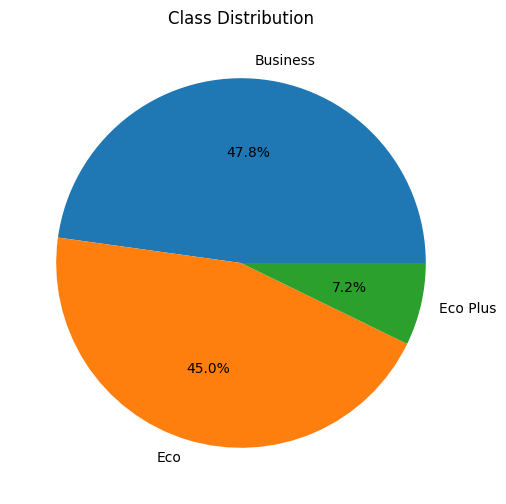

In [ ]:
plot_pie(train_df, 'satisfaction', 'Passenger Satisfaction')
plot_pie(train_df, 'Class', 'Class Distribution')

# **5-Histogram**

In [ ]:
def plot_hist(data, column, bins=20):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(6,4))
    sns.histplot(data[column], bins=bins, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

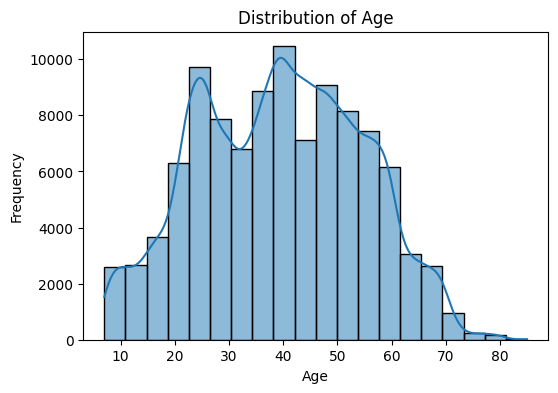

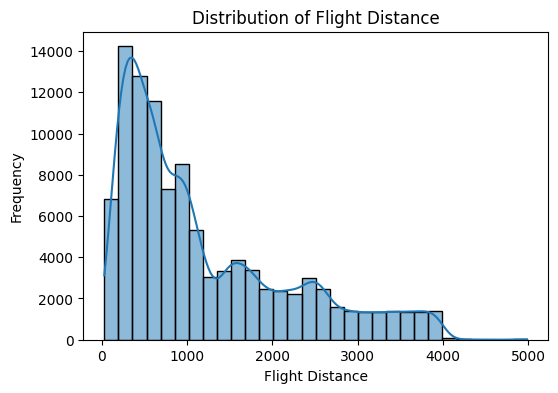

In [ ]:
plot_hist(train_df, 'Age')
plot_hist(train_df, 'Flight Distance', bins=30)

# **6-Boxplot**

In [ ]:
def plot_box(data, column):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

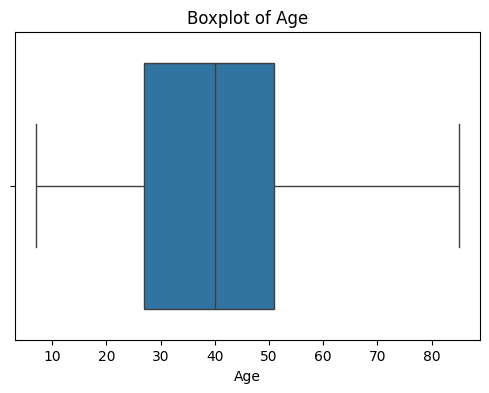

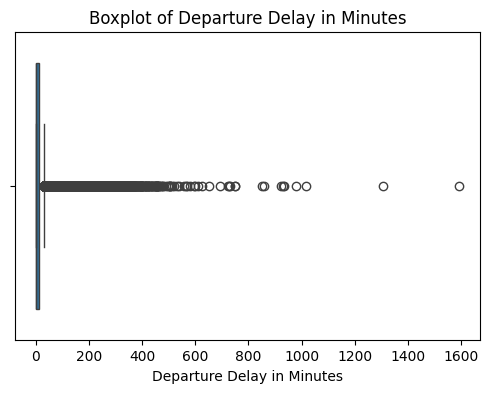

In [ ]:
plot_box(train_df, 'Age')
plot_box(train_df, 'Departure Delay in Minutes')

# **Check Missing Values**

In [ ]:
train_df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


# **Handle missing values.**

In [ ]:
median_delay = train_df["Arrival Delay in Minutes"].median()

train_df["Arrival Delay in Minutes"] = train_df["Arrival Delay in Minutes"].fillna(median_delay)
test_df["Arrival Delay in Minutes"] = test_df["Arrival Delay in Minutes"].fillna(median_delay)

In [ ]:
train_df["Arrival Delay in Minutes"].isnull().sum()

np.int64(0)

In [ ]:
test_df["Arrival Delay in Minutes"].isnull().sum()

np.int64(0)

# **Check duplicates**

In [ ]:
train_df.duplicated().sum()


np.int64(0)

# **Check type corrections**

In [ ]:
train_df.dtypes

,0
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


# **Check  Inconsistent Entries**

In [ ]:
for col in train_df.select_dtypes(include="object").columns:
    print("\n", col)
    print(train_df[col].unique())


 Gender
['Male' 'Female']

 Customer Type
['Loyal Customer' 'disloyal Customer']

 Type of Travel
['Personal Travel' 'Business travel']

 Class
['Eco Plus' 'Business' 'Eco']

 satisfaction
['neutral or dissatisfied' 'satisfied']


# **Feature Engineering**

In [ ]:


train_df['satisfaction_binary'] = train_df['satisfaction'].map(
    {'satisfied': 1, 'neutral or dissatisfied': 0}
)

test_df['satisfaction_binary'] = test_df['satisfaction'].map(
    {'satisfied': 1, 'neutral or dissatisfied': 0}
)

train_df['Delay Group'] = pd.cut(
    train_df['Departure Delay in Minutes'],
    bins=[-0.1, 5, 30, float('inf')],
    labels=['No Delay', 'Short Delay', 'Long Delay']
)

train_df['Age_Group'] = pd.cut(train_df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-Aged', 'Senior'])

train_df['Distance_Group'] = pd.qcut(
    train_df['Flight Distance'],
    q=3,
    labels=False
)


# **Pivot Tables**

In [ ]:
pivot_class = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Class',
    observed=False,
    aggfunc='mean').round(2)

pivot_travel = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Type of Travel',
    observed=False,
    aggfunc='mean').round(2)

pivot_customer = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Customer Type',
    observed=False,
    aggfunc='mean').round(2)

pivot_distance = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Distance_Group',
    columns='Class',
    aggfunc='mean',
    observed=False,
    fill_value=0).round(2)

pivot_wifi = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Inflight wifi service',
    observed=False,
    aggfunc='mean').round(2)

age_booking_pivot = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Age_Group',
    columns='Ease of Online booking',
    observed=False,
    aggfunc='mean').round(2)

pivot_digital = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Online boarding',
    columns='Ease of Online booking',
    aggfunc='mean',
    observed=False,
    fill_value=0).round(2)

service_matrix = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Seat comfort',
    columns='Food and drink',
    aggfunc='mean',
    observed=False,
    fill_value=0).round(2)

pivot_clean = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Cleanliness',
    columns='Class',
    aggfunc='mean',
    observed=False,
    fill_value=0).round(2)

delay_interaction = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Delay Group',
    columns='Checkin service',
    observed=False,
    aggfunc='mean').round(2)

advanced_pivot = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index=['Class', 'Type of Travel'],
    columns='Customer Type',
    observed=False,
    aggfunc='mean').round(2)

cool_pivot = pd.pivot_table(
    train_df,
    values='satisfaction_binary',
    index='Class',
    columns='Inflight wifi service',
    observed=False,
    aggfunc='mean').round(2)


In [ ]:

print("="*60)
print(" Airline Customer Satisfaction - Full Insight Report")
print("="*60)

print("\n[1] GENERAL CUSTOMER PROFILES")
print("-" * 30)
print("Class Impact:\n", pivot_class)
print("\nTravel Type Impact:\n", pivot_travel)
print("\nCustomer Loyalty Impact:\n", pivot_customer)


print("\n[2] LOGISTICS & DISTANCE ANALYSIS")
print("-" * 30)
print("\nFlight Distance Impact per Class:\n", pivot_distance)


print("\n[3] DIGITAL & TECH EXPERIENCE")
print("-" * 30)
print("WiFi Satisfaction Levels:\n", pivot_wifi)
print("\nAge Group vs Booking Ease:\n", age_booking_pivot)
print("\nOnline Boarding vs Booking Ease (Digital Matrix):\n", pivot_digital)


print("\n[4] IN-FLIGHT COMFORT & SERVICES")
print("-" * 30)
print("Seat Comfort vs Food and Drink Matrix:\n", service_matrix)
print("\nCleanliness vs Class:\n", pivot_clean)
print("\nDelay Impact vs Check-in Service Quality:\n", delay_interaction)


print("\n[5] MULTI-DIMENSIONAL DEEP DIVE")
print("-" * 30)
print("Class + Travel Type + Customer Loyalty:\n", advanced_pivot)
print("\nBusiness Class: Service (WiFi) vs. Prestige:\n", cool_pivot.to_string())



print("\n[6] TOP FACTORS DRIVING SATISFACTION (Correlation)")
print("-" * 30)


numeric_df = train_df.select_dtypes(include=['number'])
correlations = numeric_df.corr()['satisfaction_binary'].sort_values(ascending=False)
print(correlations)

print("\n" + "="*60)
print("END OF REPORT ")
print("="*60)

 Airline Customer Satisfaction - Full Insight Report

[1] GENERAL CUSTOMER PROFILES
------------------------------
Class Impact:
           satisfaction_binary
Class                        
Business                 0.69
Eco                      0.19
Eco Plus                 0.25

Travel Type Impact:
                  satisfaction_binary
Type of Travel                      
Business travel                 0.58
Personal Travel                 0.10

Customer Loyalty Impact:
                    satisfaction_binary
Customer Type                         
Loyal Customer                    0.48
disloyal Customer                 0.24

[2] LOGISTICS & DISTANCE ANALYSIS
------------------------------

Flight Distance Impact per Class:
 Class           Business   Eco  Eco Plus
Distance_Group                          
0                   0.60  0.20      0.27
1                   0.63  0.18      0.24
2                   0.76  0.15      0.18

[3] DIGITAL & TECH EXPERIENCE
-----------------------------

In [ ]:
def plot_box(data, column):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

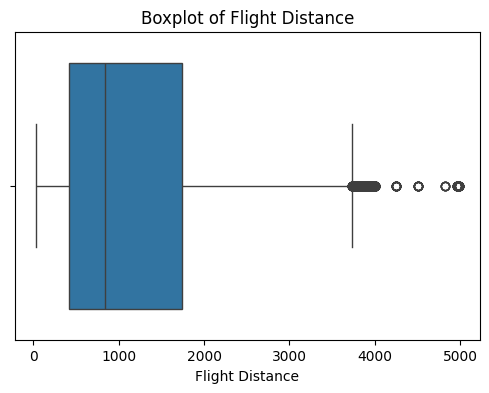

In [ ]:
plot_box(train_df, 'Flight Distance')

In [ ]:
def detect_outliers_iqr(df, column_name, print_results=True, return_outliers=True):

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_mask = (df[column_name] < lower_bound) | (df[column_name] > upper_bound)
    outliers_df = df[outliers_mask]
    outlier_indices = df[outliers_mask].index.tolist()

    if print_results:
        print("=" * 50)
        print(f"Outliers Report for column: {column_name}")
        print("=" * 50)
        print(f"Q1: {Q1:.2f}")
        print(f"Q3: {Q3:.2f}")
        print(f"IQR: {IQR:.2f}")
        print(f"Lower Bound: {lower_bound:.2f}")
        print(f"Upper Bound: {upper_bound:.2f}")
        print("-" * 50)
        print(f"Number of outliers: {len(outliers_df)}")
        print(f"Percentage: {(len(outliers_df)/len(df))*100:.2f}%")
        print("=" * 50)

        if len(outliers_df) > 0:
            print(f"\nOutliers:\n{outliers_df[[column_name]]}")

    if return_outliers:
        return outliers_df, outlier_indices
    else:
        return outlier_indices


def detect_all_outliers_iqr(train_df, print_results=True):
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

    results = {}
    for col in numeric_cols:
        outliers_df, indices = detect_outliers_iqr(train_df, col, print_results=False)
        results[col] = {
            'count': len(outliers_df),
            'percentage': (len(outliers_df)/len(train_df))*100,
            'indices': indices,
            'outliers_df': outliers_df
        }

        if print_results and len(outliers_df) > 0:
            print(f"{col}: {len(outliers_df)} outliers ({results[col]['percentage']:.2f}%)")

    return results




results = detect_all_outliers_iqr(train_df)


Flight Distance: 2291 outliers (2.20%)
Checkin service: 12891 outliers (12.41%)
Departure Delay in Minutes: 14529 outliers (13.98%)
Arrival Delay in Minutes: 13954 outliers (13.43%)


In [ ]:
Q1 = train_df['Flight Distance'].quantile(0.25)
Q3 = train_df['Flight Distance'].quantile(0.75)
IQR = Q3 - Q1
train_df = train_df[(train_df['Flight Distance'] >= Q1 - 1.5*IQR) & (train_df['Flight Distance'] <= Q3 + 1.5*IQR)]
print(len(train_df))

101613


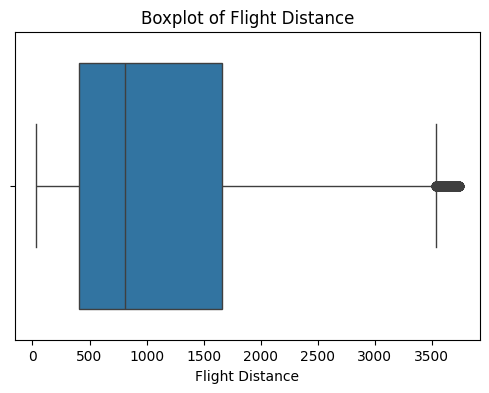

In [ ]:
plot_box(train_df, 'Flight Distance')

In [ ]:
print("Checkin service range:", train_df['Checkin service'].min(), "-", train_df['Checkin service'].max())
print("Departure Delay range:", train_df['Departure Delay in Minutes'].min(), "-", train_df['Departure Delay in Minutes'].max())

Checkin service range: 0 - 5
Departure Delay range: 0 - 1592


# **full_data_check**

In [ ]:
def full_data_check(df):
    print("DATA CLEANING REPORT")


    missing = df.isnull().sum().sum()
    print(f"\n Missing Values Total: {missing}")


    duplicates = df.duplicated().sum()
    print(f" Duplicates: {duplicates}")


    print(f" Dataset Shape: {df.shape}")


    print("\n Data Types:")
    print(df.dtypes)


    print("\n Categorical Columns Unique Values:")
    for col in df.select_dtypes(include="object").columns:
        print(f"\n- {col}:")
        print(df[col].unique())


    print("\n Missing Values Per Column:")
    print(df.isna().sum())

    print("\nDATA STATUS ")

    if missing == 0 and duplicates == 0:
        print(" Dataset is CLEAN and ready for analysis!")
    else:
        print("Dataset still needs cleaning!")

# Run it on train data
full_data_check(train_df)

DATA CLEANING REPORT

 Missing Values Total: 0
 Duplicates: 0
 Dataset Shape: (103904, 27)

 Data Types:
Gender                                 object
Customer Type                          object
Age                                     int64
Type of Travel                         object
Class                                  object
Flight Distance                         int64
Inflight wifi service                   int64
Departure/Arrival time convenient       int64
Ease of Online booking                  int64
Gate location                           int64
Food and drink                          int64
Online boarding                         int64
Seat comfort                            int64
Inflight entertainment                  int64
On-board service                        int64
Leg room service                        int64
Baggage handling                        int64
Checkin service                         int64
Inflight service                        int64
Cleanliness          

# Feature Extraction

### Feature Encoding

In [ ]:
def encode_features(df):
    df = df.copy()

    categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

### Feature Creation

In [ ]:
def create_new_features(df):
    df = df.copy()

    df.drop(columns=['Delay Group'], inplace=True, errors='ignore')

    df['Total Delay'] = (
        df['Departure Delay in Minutes'].fillna(0) +
        df['Arrival Delay in Minutes'].fillna(0)
    )

    df['Delay Level'] = pd.cut(
        df['Total Delay'],
        bins=[-0.1, 5, 30, float('inf')],
        labels=['No Delay', 'Medium Delay', 'High Delay']
    )

    df['Age_Group'] = pd.cut(
        df['Age'],
        bins=[0, 25, 50, 100],
        labels=False
    )

    return df

### Aggregation

In [ ]:
def fit_class_features(train_df):
    class_avg = train_df.groupby('Class')['Inflight service'].mean()
    return class_avg


def apply_class_features(df, class_avg):
    df = df.copy()
    df['Class_Service_Avg'] = df['Class'].map(class_avg)
    return df

In [ ]:
def feature_engineering_pipeline(train_df, test_df):

    train_df = create_new_features(train_df)
    test_df = create_new_features(test_df)

    class_avg = fit_class_features(train_df)

    train_df = apply_class_features(train_df, class_avg)
    test_df = apply_class_features(test_df, class_avg)

    train_df = encode_features(train_df)
    test_df = encode_features(test_df)

    train_df = pd.get_dummies(train_df, columns=['Delay Level'], drop_first=True)
    test_df = pd.get_dummies(test_df, columns=['Delay Level'], drop_first=True)

    train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

    return train_df, test_df

In [ ]:
train_processed, test_processed = feature_engineering_pipeline(train_df, test_df)

bool_cols = train_processed.select_dtypes(include='bool').columns
train_processed[bool_cols] = train_processed[bool_cols].astype(int)

bool_cols = test_processed.select_dtypes(include='bool').columns
test_processed[bool_cols] = test_processed[bool_cols].astype(int)

In [ ]:
train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,satisfaction_binary,Delay Group,Age_Group,Distance_Group
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,4,5,5,25,18.0,neutral or dissatisfied,0,Short Delay,Young,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,4,1,1,6.0,neutral or dissatisfied,0,No Delay,Young,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,4,4,5,0,0.0,satisfied,1,No Delay,Young,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,1,4,2,11,9.0,neutral or dissatisfied,0,Short Delay,Young,1
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,3,0,0.0,satisfied,1,No Delay,Senior,0


In [ ]:
test_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,satisfaction_binary
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,2,5,5,50,44.0,satisfied,1
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,3,4,5,0,0.0,satisfied,1
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,4,1,3,2,2,2,0,0.0,neutral or dissatisfied,0
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,3,1,4,0,6.0,satisfied,1
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,4,2,4,0,20.0,satisfied,1


In [ ]:
train_processed.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Distance_Group,Total Delay,Class_Service_Avg,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus,Delay Level_Medium Delay,Delay Level_High Delay
0,13,460,3,4,3,1,5,3,5,5,...,0,43.0,3.388444,1,0,1,0,1,0,1
1,25,235,3,2,3,3,1,3,1,1,...,0,7.0,3.844579,1,1,0,0,0,1,0
2,26,1142,2,2,2,2,5,5,5,5,...,1,0.0,3.844579,0,0,0,0,0,0,0
3,25,562,2,5,5,5,2,2,2,2,...,1,20.0,3.844579,0,0,0,0,0,1,0
4,61,214,3,3,3,3,4,5,5,3,...,0,0.0,3.844579,1,0,0,0,0,0,0


In [ ]:
test_processed.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Distance_Group,Total Delay,Class_Service_Avg,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus,Delay Level_Medium Delay,Delay Level_High Delay
0,52,160,5,4,3,4,3,4,3,5,...,0,94.0,3.463921,0,0,0,1,0,0,1
1,36,2863,1,1,3,1,5,4,5,4,...,0,0.0,3.844579,0,0,0,0,0,0,0
2,20,192,2,0,2,4,2,2,2,2,...,0,0.0,3.463921,1,1,0,1,0,0,0
3,44,3377,0,0,0,2,3,4,4,1,...,0,6.0,3.844579,1,0,0,0,0,1,0
4,49,1182,2,3,4,3,4,1,2,2,...,0,20.0,3.463921,0,0,0,1,0,1,0


In [ ]:
print(test_processed['satisfaction_binary'].value_counts())

satisfaction_binary
0    14573
1    11403
Name: count, dtype: int64


#**Feature** **Selection**

Check Constant Columns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold


In [ ]:
X=train_processed.drop(columns=['satisfaction','satisfaction_binary'])
y=train_processed['satisfaction_binary']
X_test=test_processed.drop(columns=['satisfaction','satisfaction_binary'])
y_test=test_processed['satisfaction_binary']




x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [ ]:
def check_constant_features(x_train,x_val,x_test):
  constant_var=VarianceThreshold(threshold=0)
  constant_var.fit(x_train)
  mask=constant_var.get_support()
  print(f'Number of non constant features: {mask.sum()}')
  print(f'Constant features: {x_train.columns[~mask].tolist()}')


  x_train_filtered=constant_var.transform(x_train)
  x_val_filteted=constant_var.transform(x_val)
  x_test_filtered=constant_var.transform(x_test)
  return x_train_filtered,x_val_filteted,x_test_filtered

In [ ]:
x_train_filtered,x_val_filteted,x_test_filtered=check_constant_features(x_train,x_val,X_test)

Number of non constant features: 29
Constant features: []


In [ ]:
x_train.shape,X_test.shape,x_train_filtered.shape,x_test_filtered.shape

((83123, 29), (25976, 29), (83123, 29), (25976, 29))

Check duplicated_clumns

In [ ]:
x_train_T = x_train_filtered.T
x_test_T = x_test_filtered.T

In [ ]:
type(x_train_T)

numpy.ndarray

In [ ]:
x_train_T = pd.DataFrame(x_train_T)
x_test_T = pd.DataFrame(x_test_T)

In [ ]:
x_train_T.duplicated().sum()

np.int64(0)

In [ ]:
print(test_processed['satisfaction_binary'].value_counts())

satisfaction_binary
0    14573
1    11403
Name: count, dtype: int64


In [ ]:
test_df['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,14573
satisfied,11403


Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

In [ ]:
def cal_mi(x_train,y_train):

  mi = mutual_info_classif(x_train, y_train, discrete_features=False, n_neighbors=3, random_state=3)
  mi = pd.Series(mi, index=x_train.columns).sort_values(ascending=False)

  print(f"Features with MI > 0: {(mi > 0).sum()} / {len(mi)}")
  print(f"Features with MI = 0: {(mi == 0).sum()} / {len(mi)}")
  return mi



In [ ]:
mi = cal_mi(x_train, y_train)

mi

Features with MI > 0: 29 / 29
Features with MI = 0: 0 / 29


,0
Online boarding,0.212908
Inflight wifi service,0.164048
Class_Service_Avg,0.137981
Class_Eco,0.113373
Type of Travel_Personal Travel,0.111885
Inflight entertainment,0.096528
Seat comfort,0.080926
Leg room service,0.064501
Flight Distance,0.063877
On-board service,0.059283


In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest


selector = SelectKBest(mutual_info_classif, k=20)
selector.fit(x_train, y_train)


selected_features = x_train.columns[selector.get_support()].tolist()
print(selected_features)


X_train_MI = selector.transform(x_train)
X_val_MI = selector.transform(x_val)
X_test_MI = selector.transform(X_test)

['Age', 'Flight Distance', 'Inflight wifi service', 'Ease of Online booking', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Age_Group', 'Distance_Group', 'Class_Service_Avg', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco']


In [ ]:
from sklearn.metrics import accuracy_score, f1_score,classification_report
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_MI, y_train)
pred = model.predict(X_val_MI)


print("Accuracy:", accuracy_score(y_val, pred))
print("F1:", f1_score(y_val, pred))
print(classification_report(y_val, pred))

Accuracy: 0.9610220874837592
F1: 0.9543507664562669
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.95      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



Forward Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector as SFS
def forward_feature_selection(x_train, y_train):
    sfs_forward = SFS(
        estimator=RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=0),
        n_features_to_select=20,
        tol=None,
        direction='forward',
        scoring='roc_auc',
        cv=2,
        n_jobs=-1,
    )

    sfs_forward = sfs_forward.fit(x_train, y_train)
    forward_features = x_train.columns[sfs_forward.get_support()].tolist()
    return forward_features

In [ ]:
forward_features=forward_feature_selection(x_train,y_train)
forward_features

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Ease of Online booking',
 'Gate location',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Age_Group',
 'Total Delay',
 'Class_Service_Avg',
 'Customer Type_disloyal Customer',
 'Type of Travel_Personal Travel',
 'Class_Eco',
 'Class_Eco Plus',
 'Delay Level_Medium Delay']

In [ ]:
def run_model(x_train,y_train,x_val,y_val):
  model = RandomForestClassifier(random_state=42,n_estimators=100)
  model.fit(x_train, y_train)
  pred = model.predict(x_val)


  print("Accuracy:", accuracy_score(y_val, pred))
  print("F1:", f1_score(y_val, pred))
  print(classification_report(y_val, pred))


In [ ]:
run_model(x_train[forward_features],y_train,x_val[forward_features],y_val)

Accuracy: 0.9617439006785043
F1: 0.9552893538046229
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



Backward Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector as SFS
def backward_feature_selection(x_train, y_train):
    sfs_backward = SFS(
        estimator=RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=0),
        n_features_to_select=20,
        tol=None,
        direction='backward',
        scoring='roc_auc',
        cv=3,
        n_jobs=-1,
    )

    backward = sfs_backward.fit(x_train, y_train)
    backward_features = x_train.columns[backward.get_support()].tolist()
    return backward_features

In [ ]:
backward_features=backward_feature_selection(x_train,y_train)
backward_features

['Age',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Age_Group',
 'Total Delay',
 'Class_Service_Avg',
 'Customer Type_disloyal Customer',
 'Type of Travel_Personal Travel',
 'Class_Eco']

In [ ]:
run_model(x_train[backward_features],y_train,x_val[backward_features],y_val)

Accuracy: 0.9635243732255425
F1: 0.9573486383074499
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



In [ ]:
forward_set = set(forward_features)
backward_set = set(backward_features)

common_features = forward_set.intersection(backward_set)
only_forward = forward_set - backward_set
only_backward = backward_set - forward_set
print("\nCommon Features:", common_features)
print("\nOnly Forward:", only_forward)
print("\nOnly Backward:", only_backward)


Common Features: {'Ease of Online booking', 'Age', 'On-board service', 'Total Delay', 'Type of Travel_Personal Travel', 'Age_Group', 'Checkin service', 'Class_Service_Avg', 'Customer Type_disloyal Customer', 'Inflight service', 'Inflight wifi service', 'Online boarding', 'Gate location', 'Inflight entertainment', 'Baggage handling', 'Seat comfort', 'Class_Eco'}

Only Forward: {'Class_Eco Plus', 'Flight Distance', 'Delay Level_Medium Delay'}

Only Backward: {'Cleanliness', 'Departure/Arrival time convenient', 'Leg room service'}


In [ ]:
x_train=x_train[forward_features]
x_val=x_val[forward_features]
x_test=X_test[forward_features]

### Imbalance Dataset

1- Check for imbalance

In [ ]:
y_train.value_counts()
y_train.value_counts(normalize=True)

,proportion
satisfaction_binary,
0,0.566666
1,0.433334


In [ ]:
counts = y_train.value_counts()
ratio = counts.max() / counts.min()
ratio

1.3076901721265963

2- Model Before Balancing




In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Before SMOTE:\n")
print(classification_report(y_test, y_pred))

Before SMOTE:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



3- SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(x_train, y_train)

4- Model After Balancing


In [ ]:
y_pred_res = model.predict(x_test)

print("After SMOTE:\n")
print(classification_report(y_test, y_pred_res))


After SMOTE:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



5- class weight

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(x_train, y_train)
y_pred_w = model.predict(x_test)
print("class_weight='balanced':")
print(classification_report(y_test, y_pred_w, digits=2))

class_weight='balanced':
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     14573
           1       0.97      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



# **Model** **Development**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

Logistic Regression

In [ ]:
logistic_model=LogisticRegression(max_iter=1000,random_state=42)
logistic_model.fit(x_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_pred=logistic_model.predict(x_val)
print("accuracy",accuracy_score(y_val,logistic_pred))
print("Classification Report\n",classification_report(y_val,logistic_pred))

accuracy 0.8741638997160868
Classification Report
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     11776
           1       0.86      0.84      0.85      9005

    accuracy                           0.87     20781
   macro avg       0.87      0.87      0.87     20781
weighted avg       0.87      0.87      0.87     20781



In [ ]:
logistic_pred_test=logistic_model.predict(x_test)
print("accuracy",accuracy_score(y_test,logistic_pred_test))
print("Classification Report\n",classification_report(y_test,logistic_pred_test))

accuracy 0.8690714505697567
Classification Report
               precision    recall  f1-score   support

           0       0.87      0.90      0.88     14573
           1       0.86      0.84      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976



Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [100, 200,300,400],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4,5]
}

In [ ]:
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train, y_train)


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='f1')

In [ ]:
print(grid.best_params_)
best_model = grid.best_estimator_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}


In [ ]:
pred_gb = best_model.predict(x_val)

print("Accuracy:", accuracy_score(y_val, pred_gb))
print("F1:", f1_score(y_val, pred_gb))
print(classification_report(y_val, pred_gb))

Accuracy: 0.9636687358644916
F1: 0.9575866524352564
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.95      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



In [ ]:
pred_gb_test = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred_gb_test))
print("F1:", f1_score(y_test, pred_gb_test))
print(classification_report(y_test, pred_gb_test))

Accuracy: 0.96311980289498
F1: 0.9574411372723234
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.95      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



Evaluation

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"\n🔹 {model_name} (Validation Results):")
    print("-" * 40)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print(classification_report(y_val, y_pred))

    return model, acc, f1

Random Forest

In [ ]:
def run_random_forest(X_train, y_train, X_val, y_val):

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )

    return evaluate_model(rf_model, X_train, y_train, X_val, y_val, "Random Forest")

XGBoost

In [ ]:
def run_xgboost(X_train, y_train, X_val, y_val):

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    return evaluate_model(xgb_model, X_train, y_train, X_val, y_val, "XGBoost")

In [ ]:
rf_model, acc_rf, f1_rf = run_random_forest(x_train, y_train, x_val, y_val)
xgb_model, acc_xgb, f1_xgb = run_xgboost(x_train, y_train, x_val, y_val)



🔹 Random Forest (Validation Results):
----------------------------------------
Accuracy: 0.9455271642365622
F1 Score: 0.9369148461881409
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     11776
           1       0.94      0.93      0.94      9005

    accuracy                           0.95     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.95      0.95      0.95     20781



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost (Validation Results):
----------------------------------------
Accuracy: 0.9638612193830903
F1 Score: 0.9578587060209864
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.95      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



In [ ]:
def compare_models(acc_rf, acc_xgb):

    results = {
        "Random Forest": acc_rf,
        "XGBoost": acc_xgb
    }

    print("\n🔥 Model Comparison:")
    print(results)

    best_model = max(results, key=results.get)
    print(f"\n🏆 Best Model: {best_model}")

In [ ]:
compare_models(acc_rf, acc_xgb)


🔥 Model Comparison:
{'Random Forest': 0.9455271642365622, 'XGBoost': 0.9638612193830903}

🏆 Best Model: XGBoost
